# 因子年度 Gross 与 All Costs 分析

本 notebook 直接解析 `reports/*.html` 中的 NAV 曲线，展示各因子在自然年度的 `gross`、`all_costs` 以及成本拖累。

**口径**：年度收益以该年度前一个可得年末 NAV（首年以首个可得 NAV）为起点计算；成本拖累 = `gross - all_costs`。2026 年为报告覆盖截止日之前的部分年度，不能与完整年度等权比较。

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPORT_DIR = Path.cwd().parent / 'reports'
if not REPORT_DIR.exists():
    REPORT_DIR = Path.cwd() / 'reports'

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:.1%}')
REPORT_DIR

PosixPath('/Users/dmiwu/work/PythonProject/cryptoFactorAnalyze/reports')

In [2]:
def _matched_json_array(text: str, start_at: int) -> str:
    """Return the JSON array beginning at or after start_at."""
    start = text.find('[', start_at)
    if start < 0:
        raise ValueError('NAV data array not found')
    depth, quoted, escaped = 0, False, False
    for index in range(start, len(text)):
        char = text[index]
        if quoted:
            if escaped:
                escaped = False
            elif char == '\\':
                escaped = True
            elif char == '"':
                quoted = False
        else:
            if char == '"':
                quoted = True
            elif char == '[':
                depth += 1
            elif char == ']':
                depth -= 1
                if depth == 0:
                    return text[start:index + 1]
    raise ValueError('NAV data array is not closed')


def _scenario_nav(text: str, scenario: str) -> pd.DataFrame:
    nav_section = text[text.index('var option_chart_nav'):text.index('chart_chart_nav.setOption')]
    match = re.search(r'"name":\s*"' + re.escape(scenario) + r'"', nav_section)
    if match is None:
        raise ValueError(f'{scenario} NAV series not found')
    data_match = re.search(r'"data":\s*', nav_section[match.end():])
    if data_match is None:
        raise ValueError(f'{scenario} data array not found')
    values = json.loads(_matched_json_array(nav_section, match.end() + data_match.start()))
    return pd.DataFrame(values, columns=['date', 'nav']).assign(
        date=lambda frame: pd.to_datetime(frame['date']),
        nav=lambda frame: pd.to_numeric(frame['nav']),
    )


def annual_return(nav: pd.DataFrame) -> pd.Series:
    frame = nav.sort_values('date').copy()
    frame['year'] = frame['date'].dt.year
    year_end = frame.groupby('year', sort=True)['nav'].last()
    opening_nav = year_end.shift(1)
    opening_nav.iloc[0] = frame.groupby('year', sort=True)['nav'].first().iloc[0]
    return year_end.div(opening_nav).sub(1).rename('return')


def load_yearly_returns(report_dir: Path) -> pd.DataFrame:
    records = []
    errors = []
    for report_file in sorted(report_dir.glob('*.html')):
        try:
            html = report_file.read_text(encoding='utf-8')
            gross = annual_return(_scenario_nav(html, 'gross'))
            all_costs = annual_return(_scenario_nav(html, 'all_costs'))
            for year in gross.index:
                records.append({
                    'factor': report_file.stem,
                    'year': int(year),
                    'gross': gross.loc[year],
                    'all_costs': all_costs.loc[year],
                    'cost_drag': gross.loc[year] - all_costs.loc[year],
                })
        except Exception as error:
            errors.append((report_file.name, str(error)))
    if errors:
        raise RuntimeError(f'Failed reports: {errors}')
    return pd.DataFrame(records).sort_values(['factor', 'year']).reset_index(drop=True)


yearly = load_yearly_returns(REPORT_DIR)
print(f'已读取 {yearly.factor.nunique()} 份报告，得到 {len(yearly)} 条年度观测。')
print(f'年度覆盖：{yearly.year.min()}–{yearly.year.max()}')
yearly.head()

已读取 41 份报告，得到 122 条年度观测。
年度覆盖：2024–2026


,factor,year,gross,all_costs,cost_drag
0,APB_Factor,2024,-7.1%,-51.6%,44.5%
1,APB_Factor,2025,-3.2%,-48.7%,45.5%
2,APB_Factor,2026,5.8%,-29.8%,35.6%
3,ATS_Price_Divergence_Factor,2024,-6.6%,-41.5%,34.9%
4,ATS_Price_Divergence_Factor,2025,-32.0%,-59.3%,27.4%


In [3]:
year_summary = yearly.groupby('year').agg(
    reports=('factor', 'size'),
    mean_gross=('gross', 'mean'),
    median_gross=('gross', 'median'),
    mean_all_costs=('all_costs', 'mean'),
    median_all_costs=('all_costs', 'median'),
    mean_cost_drag=('cost_drag', 'mean'),
    median_cost_drag=('cost_drag', 'median'),
    positive_all_costs=('all_costs', lambda values: (values > 0).sum()),
)
display(year_summary)

factor_summary = yearly.groupby('factor').agg(
    years=('year', 'size'),
    mean_gross=('gross', 'mean'),
    mean_all_costs=('all_costs', 'mean'),
    mean_cost_drag=('cost_drag', 'mean'),
    positive_all_cost_years=('all_costs', lambda values: (values > 0).sum()),
).sort_values('mean_all_costs', ascending=False)
display(factor_summary.head(10))

,reports,mean_gross,median_gross,mean_all_costs,median_all_costs,mean_cost_drag,median_cost_drag,positive_all_costs
year,,,,,,,,
2024,40,7.3%,7.5%,-17.2%,-14.2%,24.5%,22.3%,10
2025,41,17.7%,8.6%,-8.8%,-11.7%,26.5%,25.5%,17
2026,41,5.3%,1.5%,-12.4%,-12.2%,17.7%,14.5%,9


,years,mean_gross,mean_all_costs,mean_cost_drag,positive_all_cost_years
factor,,,,,
Retail_Friction_Illiquidity_Factor_report,3,41.3%,33.0%,8.4%,3
GP_ed2c09f43439ff39_20250101_20251231_d6750cd3a06f6cf9,2,27.9%,12.4%,15.5%,1
Net_Order_Flow_Factor,3,22.1%,9.6%,12.4%,2
Retail_Activity_Divergence_Factor,3,18.7%,6.6%,12.1%,1
Price_Momentum_60d,3,17.5%,6.5%,11.0%,2
Rank_Multiply_Factor,3,24.6%,5.2%,19.4%,2
Volatility_Order_Flow_Factor,3,33.9%,5.1%,28.8%,2
Accumulated_Buy_Sell_Ratio_Factor,3,21.7%,4.9%,16.9%,2
Intraday_Accumulation_Distribution_Factor,3,27.0%,1.7%,25.2%,1


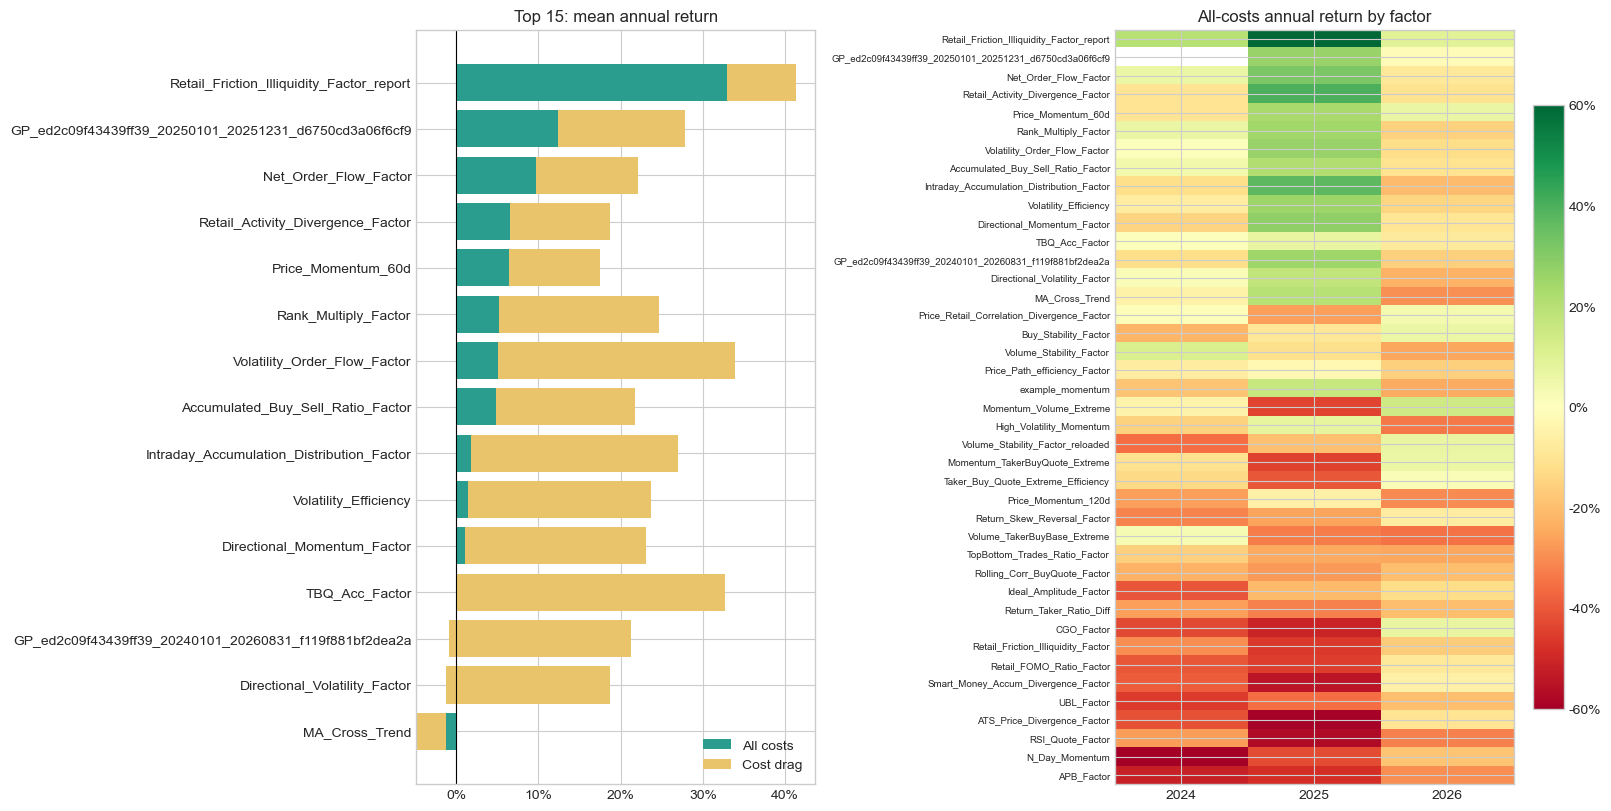

In [4]:
top_n = 15
ranking = factor_summary.head(top_n).sort_values('mean_all_costs')
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

axes[0].barh(ranking.index, ranking['mean_all_costs'], color='#2a9d8f', label='All costs')
axes[0].barh(ranking.index, ranking['mean_gross'] - ranking['mean_all_costs'],
             left=ranking['mean_all_costs'], color='#e9c46a', label='Cost drag')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[0].set_title(f'Top {top_n}: mean annual return')
axes[0].legend(loc='lower right')

annual_pivot = yearly.pivot(index='factor', columns='year', values='all_costs')
annual_pivot = annual_pivot.loc[factor_summary.index]
image = axes[1].imshow(annual_pivot, aspect='auto', cmap='RdYlGn', vmin=-0.6, vmax=0.6)
axes[1].set_xticks(range(len(annual_pivot.columns)), annual_pivot.columns)
axes[1].set_yticks(range(len(annual_pivot.index)), annual_pivot.index, fontsize=7)
axes[1].set_title('All-costs annual return by factor')
colorbar = fig.colorbar(image, ax=axes[1], shrink=0.8)
colorbar.ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.show()

## 解读框架

- **优先跟踪**：三年平均 `all_costs` 为正，且正收益年份更多。
- **成本不可承受**：`gross` 为正但 `all_costs` 显著为负，说明信号收益无法覆盖换手、滑点和资金成本。
- **版本待核对**：文件名含 `_report` 或 GP 时间窗的报告应视为独立回测版本；不能与同名原始因子直接合并。

In [5]:
stable = factor_summary.query('years >= 3 and mean_all_costs > 0 and positive_all_cost_years >= 2')
cost_limited = factor_summary.query('years >= 3 and mean_gross > 0 and mean_all_costs < 0')
version_review = factor_summary.loc[[name for name in factor_summary.index if '_report' in name or name.startswith('GP_')]]

print('优先跟踪（至少三年、成本后均值为正且至少两年为正）')
display(stable)
print('成本不可承受（gross 均值为正，但 all_costs 均值为负）')
display(cost_limited.sort_values('mean_cost_drag', ascending=False))
print('独立版本，建议核对配置和样本窗口')
display(version_review)

优先跟踪（至少三年、成本后均值为正且至少两年为正）


,years,mean_gross,mean_all_costs,mean_cost_drag,positive_all_cost_years
factor,,,,,
Retail_Friction_Illiquidity_Factor_report,3,41.3%,33.0%,8.4%,3
Net_Order_Flow_Factor,3,22.1%,9.6%,12.4%,2
Price_Momentum_60d,3,17.5%,6.5%,11.0%,2
Rank_Multiply_Factor,3,24.6%,5.2%,19.4%,2
Volatility_Order_Flow_Factor,3,33.9%,5.1%,28.8%,2
Accumulated_Buy_Sell_Ratio_Factor,3,21.7%,4.9%,16.9%,2


成本不可承受（gross 均值为正，但 all_costs 均值为负）


,years,mean_gross,mean_all_costs,mean_cost_drag,positive_all_cost_years
factor,,,,,
UBL_Factor,3,34.0%,-33.8%,67.8%,0
N_Day_Momentum,3,22.9%,-40.8%,63.7%,0
CGO_Factor,3,9.0%,-29.1%,38.1%,1
TBQ_Acc_Factor,3,32.7%,-0.0%,32.8%,2
Momentum_Volume_Extreme,3,19.1%,-11.4%,30.5%,1
Price_Path_efficiency_Factor,3,21.5%,-8.5%,29.9%,0
High_Volatility_Momentum,3,15.3%,-13.8%,29.2%,1
Rolling_Corr_BuyQuote_Factor,3,3.9%,-23.5%,27.4%,0
Momentum_TakerBuyQuote_Extreme,3,9.7%,-16.4%,26.2%,1


独立版本，建议核对配置和样本窗口


,years,mean_gross,mean_all_costs,mean_cost_drag,positive_all_cost_years
factor,,,,,
Retail_Friction_Illiquidity_Factor_report,3,41.3%,33.0%,8.4%,3
GP_ed2c09f43439ff39_20250101_20251231_d6750cd3a06f6cf9,2,27.9%,12.4%,15.5%,1
GP_ed2c09f43439ff39_20240101_20260831_f119f881bf2dea2a,3,21.3%,-0.9%,22.2%,1


## 全量年度明细

下表用于复核每份报告、每个自然年度的计算结果。

In [6]:
display(
    yearly.style
    .format({'gross': '{:.1%}', 'all_costs': '{:.1%}', 'cost_drag': '{:.1%}'})
    .background_gradient(subset=['all_costs'], cmap='RdYlGn', vmin=-0.6, vmax=0.6)
    .background_gradient(subset=['cost_drag'], cmap='YlOrRd')
)

,factor,year,gross,all_costs,cost_drag
0,APB_Factor,2024,-7.1%,-51.6%,44.5%
1,APB_Factor,2025,-3.2%,-48.7%,45.5%
2,APB_Factor,2026,5.8%,-29.8%,35.6%
3,ATS_Price_Divergence_Factor,2024,-6.6%,-41.5%,34.9%
4,ATS_Price_Divergence_Factor,2025,-32.0%,-59.3%,27.4%
5,ATS_Price_Divergence_Factor,2026,20.4%,-10.2%,30.6%
6,Accumulated_Buy_Sell_Ratio_Factor,2024,23.4%,3.8%,19.5%
7,Accumulated_Buy_Sell_Ratio_Factor,2025,44.1%,21.5%,22.6%
8,Accumulated_Buy_Sell_Ratio_Factor,2026,-2.2%,-10.7%,8.4%
9,Buy_Stability_Factor,2024,-7.6%,-21.8%,14.1%
